# **Implementation Analysis**

## **Objective & Data Structure:**
In this project we want to implement a recommender system using `collaborative filtering` method. The core data structure used in this implementation is a `user-item matrix` which represents the ratings given by users to movies. Each row corresponds to a user, each column corresponds to a movie, and the cell values represent the user's rating for that movie. NaN values are filled with 0, representing no rating from a specific user.
A `pandas DataFrame` is used to store this matrix and other relevant data. DataFrame provides efficient storage and manipulation for tabular data. Furthermore, a `movie_similarity_df` is created to store the cosine similarity scores between different movies. This is a square matrix where the elements represent the similarity between two given movies based on cosine similarity of their vectores.  

### **Load Data, Import Libraries and Basic EDA**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import requests
import zipfile
import io

In [2]:
file_location = 'https://phparis.net/uploads/m2_ds_algods_ratings.zip'

# Download the zip file
response = requests.get(file_location)

# Extract the zip file into memory
with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
  # find its name and extract it to a dataframe.
  csv_filename = [name for name in zip_ref.namelist() if name.endswith('.csv')][0]
  with zip_ref.open(csv_filename) as csv_file:
    df = pd.read_csv(csv_file)

print(df.head(10))

   user_id  movie_id  rating  timestamp
0     5412      2683       2  960243649
1     5440       904       5  959995181
2      368      3717       4  976311423
3      425      1721       4  976283587
4     4942      3697       1  962642480
5     4668      2011       4  963801714
6     2907       173       5  971820825
7     2376      1829       3  974336102
8     3824      1959       1  965940852
9     5605       277       1  959560081


In order to evaluate our model performance and fine-tune the parameters, we select a portion of data (1%) as test data to use in final test.

In [3]:
from sklearn.model_selection import train_test_split

# Split the DataFrame into training and testing sets
train_df, test_df = train_test_split(df, test_size=0.01, random_state=42)
test_df = pd.DataFrame(test_df)
test_df.to_csv('test_data.csv', index=False, header=True)

print(f"Training set shape: {train_df.shape}")
print(f"Testing set shape: {test_df.shape}")

Training set shape: (792165, 4)
Testing set shape: (8002, 4)


Now we should look at dataset in order to find any null values.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800167 entries, 0 to 800166
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    800167 non-null  int64
 1   movie_id   800167 non-null  int64
 2   rating     800167 non-null  int64
 3   timestamp  800167 non-null  int64
dtypes: int64(4)
memory usage: 24.4 MB


***Attributes and Information:***

1. user_Id : Every user identified with a unique id
2. movie_Id : Every movie identified with a unique id
3.Rating : Rating of the corresponding movie by the corresponding user from 1 to 5
4.timestamp : Time of the rating.


As we can see there is no null values in our dataset.Now we can look at the distribution of rating among users.

In [5]:
print(df[['rating']].describe().transpose())

           count     mean       std  min  25%  50%  75%  max
rating  800167.0  3.58149  1.117253  1.0  3.0  4.0  4.0  5.0


**Rating** : This is can be considered as categorical attribute with values of (1,2,3,4,5). The mean rating is 3.58 which means most of the users have given average ratings for the movies i.e. many records with ratings equal or above 3. This can be seen from the median (Q2), 75% (Q3) as 4 and max values as 5. Even 25% (Q1) value is 3.0. The distrubution of ratings can be seen as follows:


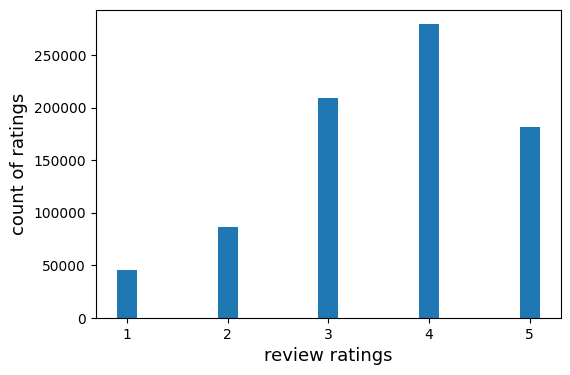

In [6]:
fig = plt.figure(figsize=(6,4))
ax  = fig.add_subplot(111)
ax.hist(df['rating'], bins=[0.9, 1.1, 1.9, 2.1, 2.9, 3.1, 3.9, 4.1, 4.9, 5.1])
ax.set_xlabel('review ratings', fontsize=13)
ax.set_ylabel('count of ratings', fontsize=13)
plt.show()

**Drop timestamp attribute**

In [7]:
df.drop('timestamp', axis=1 , inplace= True)

**Unique users and movies count**

In [8]:
print('total number of unique users in dataset',df['user_id'].nunique())
print('total number of unique movies in dataset',df['movie_id'].nunique())

total number of unique users in dataset 6040
total number of unique movies in dataset 3675


**Determine number of ratings for each user**

In [9]:
num_reviews_per_person = df.groupby('user_id')['movie_id'].count()
print("Avg Number of ratings per user {}".format(num_reviews_per_person.mean()))
print("Max Number of ratings per user {}".format(num_reviews_per_person.max()))
print("Min Number of ratings per user {}".format(num_reviews_per_person.min()))

Avg Number of ratings per user 132.47798013245034
Max Number of ratings per user 1858
Min Number of ratings per user 10


We will create a new dataframe called ratings_mean_count and first add the average rating of each movie to this dataframe as follows-

In [10]:
ratings_mean_count = pd.DataFrame(df.groupby('movie_id')['rating'].mean())

Next up, we will add the number of ratings for a movie to the ratings_mean_count dataframe as follows-


In [11]:
ratings_mean_count['rating_counts'] = pd.DataFrame(df.groupby('movie_id')['rating'].count())
print(ratings_mean_count.head(10))

            rating  rating_counts
movie_id                         
1         4.139398           1693
2         3.195652            552
3         3.005208            384
4         2.727941            136
5         2.982759            232
6         3.892999            757
7         3.434426            366
8         3.176471             51
9         2.621951             82
10        3.531469            715


<Axes: >

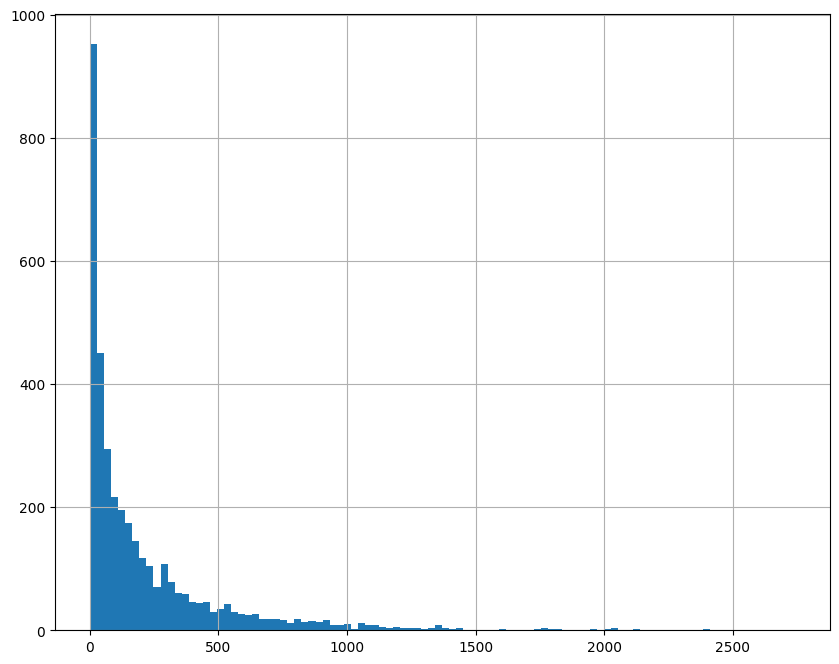

In [12]:
plt.figure(figsize=(10,8))
ratings_mean_count['rating_counts'].hist(bins=100)

From the above plot, we can see that most of the movies have received less than 500 ratings and there are less movies having more than 1000 ratings.


## **Reasons to Consider Item-to-Item Collaborative Filtering insted of User-to-User**

1. **Scalability and Performance:**
   - In our case, with a large number of users, user-to-user filtering can be computationally expensive (there are 6040 unique users versus 3675 unique movies ). Finding similar users can be a time-consuming task.
   - Item-to-item filtering, on the other hand, is typically more scalable. The similarity between items is often relatively stable and can be precomputed. This precomputation allows for faster recommendations during runtime.


2. **Sparse User Data:**
   - Users may rate only a few items(as we can see there are users who only rate 10 movies and in maximum way rate approximately half of the movies 1858). This leads to sparse user profiles, making it difficult to accurately find similar users.
   - Item-to-item can work well even with sparse user data because it focuses on the relationship between items. If two items are frequently rated together by different users, we can infer that they are similar even if the users themselves have sparse ratings.


3. **Item Stability:**
   - Users' preferences can change over time, which makes user-to-user filtering somewhat less stable.
   - Item similarities are often more stable. If a group of users liked "The Lord of the Rings" and "The Hobbit," it's likely that this pattern will persist for a longer time than user preference changes.


4. **Improved Recommendations for New Users:**
   - When a new user joins the system, it's hard to find similar users immediately.
   - Item-to-item can still provide reasonable recommendations by leveraging the established item similarity relationships. If the new user likes one item, we can recommend similar items based on the precomputed item similarities. For example, If a user rates "The Shining" highly, we can recommend "Sinister" because we have established that these two movies are frequently rated together by other users. This recommendation doesn't rely on finding a user who has a similar taste to the current user, instead it leverages the item similarity between the movies directly.




We need to create a matrix where each column is a movie id and each row contains the rating assigned by a specific user to that movie. This matrix will have a lot of null values since every movie is not rated by every user. We will create the matrix of movie_id and corresponding user ratings.


In [13]:
user_item_matrix = df.pivot_table(index='user_id', columns='movie_id', values='rating')
user_item_matrix.head(10)

movie_id,1,2,3,4,5,6,7,8,9,10,...,3943,3944,3945,3946,3947,3948,3949,3950,3951,3952
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,4.0,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN


In [14]:
# Fill NaN values with 0 (meaning the user hasn't rated the movie)
user_item_matrix = user_item_matrix.fillna(0)

we can see the sparsity of this matrix as following:

In [15]:
sparsity = float(len(user_item_matrix.to_numpy().nonzero()[0]))
sparsity /= (user_item_matrix.shape[0] * user_item_matrix.shape[1])
sparsity *= 100
print("Sparsity: {:4.2f}%".format(sparsity))

Sparsity: 3.60%


Now we show the calculation of cosine similarities between movies(item-item) from scratch. It is not considered optimal in resource allocation and time of calculation. Since there is an optimal verctorized library in Sklearn to return this heavy calculation (O 3600^2) we will use that in our final recommender algorithm.

In [16]:
def cosine_similarity_scratch(vector1, vector2):
  """
  Calculate the cosine similarity between two vectors.

  Args:
    vector1: The first vector.
    vector2: The second vector.

  Returns:
    The cosine similarity between the two vectors.
  """
  dot_product = np.dot(vector1, vector2)
  magnitude_vector1 = np.linalg.norm(vector1)
  magnitude_vector2 = np.linalg.norm(vector2)
  if magnitude_vector1 == 0 or magnitude_vector2 == 0:
    return 0  # Handle cases where one or both vectors have zero magnitude
  cosine_similarity_scratch = dot_product / (magnitude_vector1 * magnitude_vector2)
  return cosine_similarity_scratch

In [ ]:
movie_similarity = np.zeros((user_item_matrix.shape[1], user_item_matrix.shape[1]))
for i in range(user_item_matrix.shape[1]):
  for j in range(i, user_item_matrix.shape[1]):
    movie_i_vector = user_item_matrix.iloc[:, i].values
    movie_j_vector = user_item_matrix.iloc[:, j].values
    similarity = cosine_similarity_scratch (movie_i_vector, movie_j_vector)
    movie_similarity[i, j] = similarity
    movie_similarity[j, i] = similarity

movie_similarity_df = pd.DataFrame(movie_similarity, index=user_item_matrix.columns, columns=user_item_matrix.columns)
movie_similarity_df.head(10)

In [17]:
# Calculate cosine similarity between movies (item-to-item)
movie_similarity = cosine_similarity(user_item_matrix.T)
movie_similarity_df = pd.DataFrame(movie_similarity, index=user_item_matrix.columns, columns=user_item_matrix.columns)
print(movie_similarity_df.head(10))

movie_id      1         2         3         4         5         6     \
movie_id                                                               
1         1.000000  0.306919  0.200327  0.136721  0.197376  0.278412   
2         0.306919  1.000000  0.204602  0.126866  0.203671  0.200241   
3         0.200327  0.204602  1.000000  0.165122  0.252018  0.157374   
4         0.136721  0.126866  0.165122  1.000000  0.231629  0.107153   
5         0.197376  0.203671  0.252018  0.231629  1.000000  0.131258   
6         0.278412  0.200241  0.157374  0.107153  0.131258  1.000000   
7         0.235776  0.192632  0.227628  0.160790  0.235786  0.150073   
8         0.090328  0.132255  0.068536  0.055909  0.070525  0.042678   
9         0.082599  0.135231  0.091582  0.047088  0.124682  0.146076   
10        0.328742  0.337208  0.198450  0.106955  0.194537  0.341991   

movie_id      7         8         9         10    ...      3943      3944  \
movie_id                                          ...     

In this step, after contructing the similar matrix for each movie based on cosine similarity metric, we should use the computed similarities to predict missing ratings in our first matrix of users and movies.

In [18]:
def predict_rating(user_id, movie_id):
  """Predicts a user's rating for a movie using item-based collaborative filtering."""
  user_ratings = user_item_matrix.loc[user_id]
  movie_similarities = movie_similarity_df[movie_id]

  # Weighted average of ratings for similar movies
  predicted_rating = np.dot(user_ratings, movie_similarities) / np.sum(np.abs(movie_similarities))

  return predicted_rating

Now we recommend for each user, a list of 5 movies with high rating based on our predicted ratings.

In [19]:
def recommend_movies(user_id, num_recommendations=5):
  """Recommends movies for a user based on predicted ratings."""
  unrated_movies = user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] == 0].index.tolist()
  predicted_ratings = {}
  for movie_id in unrated_movies:
    predicted_ratings[movie_id] = predict_rating(user_id, movie_id)

   # Sort movies by predicted rating in descending order
    sorted_predictions = dict(sorted(predicted_ratings.items(), key=lambda item: item[1], reverse=True))

  # Return the top N recommended movies
  return list(sorted_predictions.keys())[:num_recommendations]

Now we can run a test of our function

In [20]:
user_id_to_recommend = 1100
num_recommendations = 5
recommendations = recommend_movies(user_id_to_recommend,num_recommendations)
print(f"Recommended movies for user {user_id_to_recommend}: {recommendations}")

Recommended movies for user 1100: [658, 1815, 2251, 1851, 576]


We can determine the similarity threshold to put condition on recommendations in order to be considered. And we can complete our recommender system function as following:

In [21]:
def recommend_movies_with_threshold(ratings_file, similarity_threshold=None):
    """
    Recommends movies based on user ratings and an optional similarity threshold.

    Args:
        ratings_file: Path to the CSV file containing user-movie ratings.
        similarity_threshold: The minimum similarity score for a recommendation to be considered.

    Returns:
        A list of tuples (user_id, movie_id, predicted_rating).
    """
    df = pd.read_csv(ratings_file)

    # Create user-item matrix
    user_item_matrix = df.pivot_table(index='user_id', columns='movie_id', values='rating').fillna(0)

    # Calculate cosine similarity between movies
    movie_similarity = cosine_similarity(user_item_matrix.T)
    movie_similarity_df = pd.DataFrame(movie_similarity, index=user_item_matrix.columns, columns=user_item_matrix.columns)

    def predict_rating(user_id, movie_id):
        """Predicts a user's rating for a movie using item-based collaborative filtering."""
        user_ratings = user_item_matrix.loc[user_id]
        movie_similarities = movie_similarity_df[movie_id]

        # Weighted average of ratings for similar movies
        predicted_rating = np.dot(user_ratings, movie_similarities) / np.sum(np.abs(movie_similarities))

        return predicted_rating

    def recommend_movies(user_id, num_recommendations=5):
        """Recommends movies for a user based on predicted ratings."""
        unrated_movies = user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] == 0].index.tolist()
        predicted_ratings = {}
        for movie_id in unrated_movies:
            predicted_ratings[movie_id] = predict_rating(user_id, movie_id)

        # Sort movies by predicted rating in descending order
        sorted_predictions = dict(sorted(predicted_ratings.items(), key=lambda item: item[1], reverse=True))

        # Return the top N recommended movies
        return list(sorted_predictions.keys())[:num_recommendations]


    recommendations = []
    for user_id in user_item_matrix.index:
        for movie_id in recommend_movies(user_id):
            predicted_rating = predict_rating(user_id, movie_id)
            if similarity_threshold is None or predicted_rating >= similarity_threshold:
                recommendations.append((user_id, movie_id, predicted_rating))

    return recommendations

## **Optimizations:**

*    **Cosine Similarity Calculation using Scikit-learn:** The cosine similarity between movies is calculated using `sklearn.metrics.pairwise.cosine_similarity`, which provides an efficient vectorized implementation. This is a significant improvement over the naive nested loop implementation (`cosine_similarity_scratch`) for calculating paiwise cosine similarity.

*  **Efficient Prediction:** The `predict_rating` function uses a weighted average rating for similar movies to predict the user's rating for a specific movie. This is a computationally efficient approach compared to mpre complex models.


*  **Data Filtering:** During recommendation, the `recommend_movies` function focuses on predicting ratings for only those movies that user has not rated yet. This reduces the computational load during prediction.














## **Potential Improvements :**


1.  **Sparsity Handling:** The user-item matrix can be very sparse, especially in large datasets like our case. Techniques like singular decomposition (SVD) or matrix factorization could be used to reduce dimensionality and improve prediction accuracy.
2.   **Memory Efficiency:** Techniques like sparse matrix representation or distrubuted computing could be considered to reduce memory footprint.
1.   **Advanced Similarity Metrics:** While cosine similarity is a good baselin, alternative similarity metrics like Pearson correlation or adjusted cosine similarity could be explored to potentially improve the quality of recommendations.


# **Experiment Setup**

1. **Data Splitting**: Divide the dataset into a training set and a test set.
 The training set will be used to calculate movie similarities and build the recommender system.
  The test set will be used to evaluate the performance of the system.


2. **Recommendation Generation**: Use the trained model to generate a list of recommended movies for each user in the test set.


3. **Performance Evaluation**: Calculate the chosen evaluation metrics
 (e.g., precision, recall, RMSE, MAP) on the generated recommendations compared to the actual ratings in the test set.


 **Evaluation Methodology**

To evaluate the performance of the recommender system, we can use metrics like:

* **Precision and Recall**: Measures the accuracy of the recommendations. Precision quantifies how many of the recommended items are actually relevant to the user, while recall quantifies how many of the relevant items were actually recommended.

* **Root Mean Squared Error (RMSE)**: Measures the average difference between the predicted ratings and the actual ratings. This metric can be used to assess the accuracy of the rating prediction model.






In [ ]:
def evaluate_recommender(test_df, recommendations):
  """Evaluates the recommender system using RMSE, precision, and recall.

  Args:
    test_df: DataFrame containing user-movie ratings for the test set.
    recommendations: List of tuples (user_id, movie_id, predicted_rating).

  Returns:
    A dictionary containing the RMSE, precision, and recall scores.
  """
  true_ratings = []
  predicted_ratings = []

  for user_id, movie_id, predicted_rating in recommendations:
    actual_rating = test_df[(test_df['user_id'] == user_id) & (test_df['movie_id'] == movie_id)]['rating']
    if not actual_rating.empty:
        true_ratings.append(actual_rating.iloc[0])
        predicted_ratings.append(predicted_rating)

 # Calculate RMSE
  rmse = np.sqrt(np.mean((np.array(true_ratings) - np.array(predicted_ratings))**2))

  # Calculate precision and recall
  ''' in order to filter relevant recommendation for true and false label classification,
   we determine a threshold = 3.5 for predicted_ratings.'''

  relevant_recommendations = [(user_id, movie_id) for user_id, movie_id, predicted_rating in recommendations if predicted_rating >= 3.5]
  true_positives = 0
  false_positives = 0
  false_negatives = 0

  for user_id, movie_id in relevant_recommendations:
    actual_rating = test_df[(test_df['user_id'] == user_id) & (test_df['movie_id'] == movie_id)]['rating']
    if not actual_rating.empty and actual_rating.iloc[0] >= 3.5:
      true_positives += 1
    elif not actual_rating.empty and actual_rating.iloc[0] < 3.5:
      false_positives += 1
    else:
      false_positives +=1

  # Iterate through the test set to count true negatives and false negatives
  for user_id in test_df['user_id'].unique():
    for movie_id in test_df['movie_id'].unique():
        if (user_id, movie_id) not in relevant_recommendations:
            actual_rating = test_df[(test_df['user_id'] == user_id) & (test_df['movie_id'] == movie_id)]['rating']
            if not actual_rating.empty and actual_rating.iloc[0] >= 3.5:
                false_negatives += 1
  if true_positives + false_positives == 0:
    precision = 0
  else:
    precision = true_positives / (true_positives + false_positives)

  if true_positives + false_negatives == 0:
    recall = 0
  else:
    recall = true_positives / (true_positives + false_negatives)

  return {'rmse': rmse, 'precision': precision, 'recall': recall}

# Load the test data
test_df = pd.read_csv('test_data.csv')

# Assume 'recommendations' is a list of (user_id, movie_id, predicted_rating) tuples
recommendations = recommend_movies_with_threshold('test_data.csv')

# Evaluate the recommender
evaluation_results = evaluate_recommender(test_df, recommendations)
evaluation_results

# **Results and Discussion**

 We would analyze the performance of the recommender system based on the chosen metrics. For example, we would investigate:

* **Overall performance**: How accurate are the recommendations overall?


* **Sensitivity to parameters**: How does the performance change with different values of the similarity threshold or
 other parameters?


* **Comparison to other methods**: How does the performance of the item-based collaborative filtering method compare
 to other methods, such as content-based filtering or user-based collaborative filtering?


The results would be used to discuss the strengths and weaknesses of the implementation.
 Any limitations or areas for further improvement would be highlighted.
